In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('notebook')
from IPython.display import display, Audio

# Ejercicios

## Ejercicios señales (1):

### Ejercicio 1.1

Construir una dientes de sierra a partir de integrar un tren de pulsos. Considerar como transformar el tren de pulsos con operaciones básicas previamente a integrar.

### Ejercicio 1.2

Utilizando solo operaciones vectorizadas de numpy (no fors), calcular cuantos pulsos hay en la siguiente señal

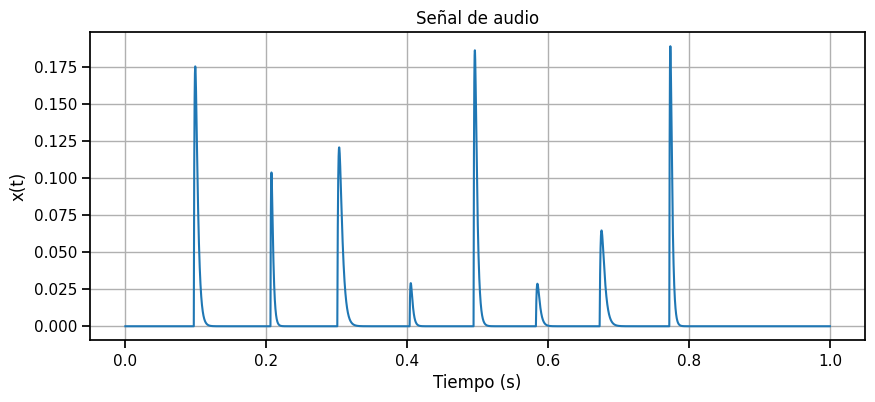

In [4]:
sr = 16000
dur = 1
t = np.arange(0, int(dur*sr))/sr 
x = np.zeros(len(t))
ts = np.arange(0, 800)/sr
ix = 0
n_pulsos = 8
for i in range(n_pulsos):
    ix += int(np.random.uniform(0.7,0.95)*(len(t))/n_pulsos)
    ix = min(ix, len(t)-len(ts))
    s = np.random.uniform(200, 500)
    A = np.random.uniform(0.1, 1)
    xs = A*np.exp(-ts*s)*(1-np.exp(-ts*s))
    x[ix:ix+len(ts)] = xs

plt.figure(figsize=(10, 4))
plt.plot(t, x)
plt.xlabel('Tiempo (s)')
plt.ylabel('x(t)');
plt.grid(True)
plt.title('Señal de audio');
plt.show()

Audio(x, rate=sr)

### Ejercicio 1.3

Dada una señal que tiene una series de impulsos en distintos instantes, calcular los tiempos entre impulsos a partir de operaciones vectorizadas (no fors)


Tiempos entre pulsos:
[0.101625  0.038625  0.1094375 0.0824375 0.0695    0.1464375 0.1614375
 0.065375  0.0420625]


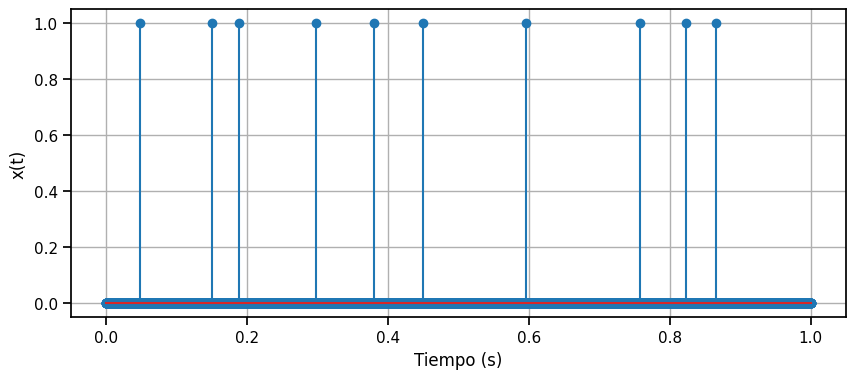

In [5]:
x = np.zeros(int(dur*sr))
ps = sorted(np.random.randint(0, int(dur*sr), 10))
print("Tiempos entre pulsos:")
print(np.diff(ps)/sr)
x[ps] = 1

plt.figure(figsize=(10, 4))
plt.stem(t, x, 'o')
plt.xlabel('Tiempo (s)')
plt.ylabel('x(t)');
plt.grid(True)
plt.show()

### Ejercicio 1.4

Considerando señales continuas y la definición de valor medio como la integral

$$
\mu = \lim_{T \to \infty} \frac{1}{T} \int_{-T/2}^{T/2} x(t) dt
$$

Calcular el valor medio de una señal cuadrada de frecuencia f y amplitud A en un sólo período.

Calcular el valor medio de una función escalón de amplitud A.

Luego hacerlo con la definición de valor medio como primer momento de la densidad de la señal.

$$
\mu = \int_{-\infty}^{\infty} x p(x) dx
$$

### Ejercicio 1.5

Calcular analiticamente la PDF de una señal senoidal. Comparar con un histograma hecho a partir de los valores de la señal. Más información en el capítulo 16, Signal, Sound de Sensation. W. Hartmann.

A partir de un período de la señal

$$
x = \sin(t)\; \text{para}\; 0 \leq t \leq 2\pi
$$

Considerar que la densidad en función de $x$ depende de cuanto tiempo pase la señal en ese valor. Como el tiempo total es $2\pi$, dividimos por $2\pi$ para normalizar.

$$
p(x) = \frac{dt}{2\pi dx}
$$

Integral de la densidad de probabilidad

$$
\int_{-\infty}^{\infty} p(x) dx = \int_{-\infty}^{\infty} \frac{dt}{2\pi dx} dx = \frac{1}{2\pi} \int_{-\infty}^{\infty} dt = \frac{1}{2\pi} 2\pi = 1
$$

Derivar $t = \sin^{-1}(x)$ en función de $x$

### Ejercicio 1.6

En base al resultado anterior, calcular la potencia de la señal senoidal utilizando la expresión de la varianza con media cero.

$$
P = Var[x(t)] = \int_{-\infty}^{\infty} x^2 p(x) dx
$$

## Ejercicios Convolución y Respuesta de Sistemas(2):

### Ejercicio 2.1

Demostrar las propiedades de conmutación, asocialidad y distribución de la convolución.

### Ejercicio 2.2

Tomar el ejemplo de síntesis granular con convolución y utilizar una señal de entrada que logre un efecto de modulación en la frecuencia fundamental de la señal de salida. Para hacer esto utilizar un paso variable entre impulsos que tenga una modulación lenta. Por ejemplo ir de $f0=330$ a $f0=660$. También reemplazar el impulso de una sola muestra por un pequño pulso gaussiano de ancho controlable para lograr una transición más suave.

### Ejercicio 2.3

Expresar la convolución discreta como operaciones de álgebra lineal construyendo una matriz de Toeplitz con una señal y multiplicando por  un vector con otra señal.

### Ejercicio 2.4

Calcular como responden los siguientes sistemas a entradas exponenciales complejas $x(t) = e^{j\omega t}$. Expresar la salida como un producto por la función de transferencia compleja $y(t) = H(j\omega)e^{j\omega t}$

Filtros pasa bajos

$$
y(t) = \int_{-\infty}^{\infty} x(t) dt
$$

$$
\frac{dy(t)}{dt} = \frac{x(t)-y(t)}{\tau}
$$

Filtros pasa altos

$$
y(t) = \frac{d}{dt} x(t)
$$

$$
\frac{dy(t)}{dt} = \frac{dx(t)}{dt}-\frac{y(t)}{\tau}
$$


## Ejercicios Series de Fourier (3):

### Ejercicio 3.1

Sintetiador de audio aditivo limitado en frecuencia. A partir de una nota fundamental $f0$ y una frecuencia de muestreo $sr = 48000$, plantear un sistema que descomponga en Fourier señales discretas arbitrarias de largo $N=sr/f0$ muestras. Obtener los coeficientes de Fourier proyectando en la base y realizar la síntesis en base a coeficientes de fourier $c_n$ hasta $nf0<sr/2$ o lo mismo $n<N/2$.

Sonificar el resultado generando varios ciclos hasta 1 segundo. Analizar con auriculares la calidad del audio comparando con la escucha de la señal original. Probar con una onda dientes se sierra.


### Ejercicio 3.2

Comparación de 2 métodos para obtener la suma de Fourier hasta la componente $n<N/2$. Primero en base a la proyección de la señal en la base de Fourier y luego en base a la convolución rápida (*fftconvolve*) de la señal con el kernel de Dirichlet de grado $n$. 
$$
{\displaystyle D_{n}(x)=\sum _{k=-n}^{n}e^{ikx}=\left(1+2\sum _{k=1}^{n}\cos(kx)\right)={\frac {\sin \left(\left(n+1/2\right)x\right)}{\sin(x/2)}},}
$$

Comparar la velocidad de ambos métodos y la calidad de la señal obtenida, en términos del error a la señal de entrada.

### Ejercicio 3.3

Crear un sintetizador que tome como entrada un grafo al cual se le calcula la matriz Laplacia, luego sus autovectores y autovalores. Proyectar una condición inicial (por ejemplo una delta) sobre la matriz de autovectores y sintetizar las oscilaciones usando la raiz de los autovectores como frecuencias. Probar con un grafo tipo grilla 2D. Visualizar tipo heatmap 2D los autovectoes.


### Ejercicio 3.4

Hacer un punteo de los distintos tipos de convergencia que se plantean para el desarrollo en series de Fourier. Demostrar al menos uno.
